# Data visualization


## National data
First we can plot the data for the time series on national data, with the relative correlations.
In the case of te national features is easier to print all the possible correlations in different forms.

In [49]:
import pandas as pd

df = pd.read_csv("../data/output/national_features.csv")
df = df.set_index("delivery_timestamp")
df.rename(columns={"fixing_i_price_first": "fixing_i_price", "business_date_first": "business_date"}, inplace=True)

# choose a specific time window
start, end = "2024-01-01", "2024-03-31"
df_slice = df.loc[start:end]

### Time series plot

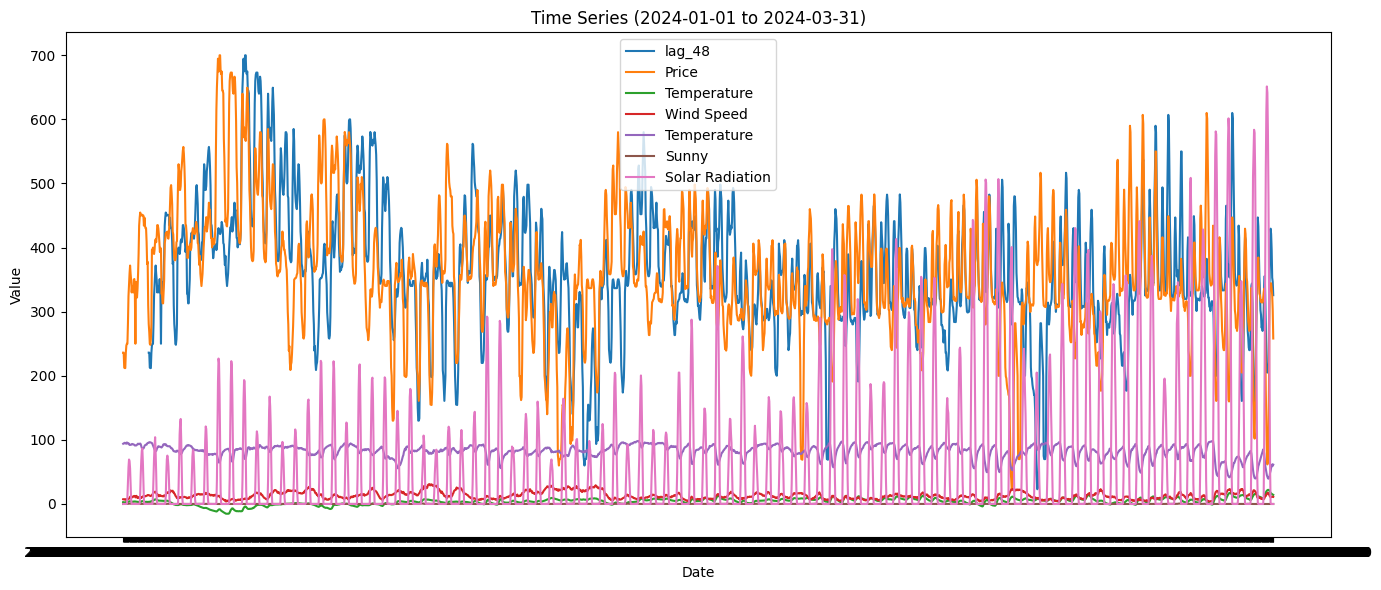

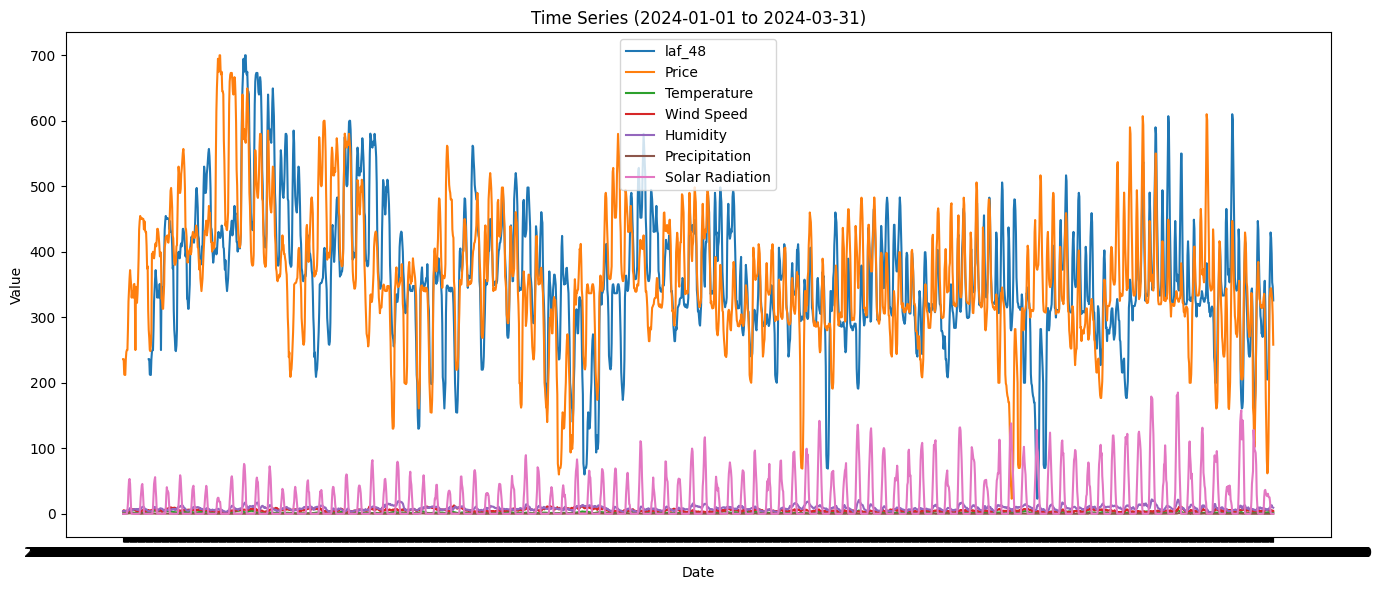

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
plt.plot(df_slice.index, df_slice["lag_48"], label="lag_48")
plt.plot(df_slice.index, df_slice["fixing_i_price"], label="Price")
plt.plot(df_slice.index, df_slice["temperature_mean"], label="Temperature")
plt.plot(df_slice.index, df_slice["wind_speed_mean"], label="Wind Speed")
plt.plot(df_slice.index, df_slice["humidity_mean"], label="Temperature")
plt.plot(df_slice.index, df_slice["precipitation_mean"], label="Sunny")
plt.plot(df_slice.index, df_slice["sunny_mean"], label="Solar Radiation")
plt.title("Time Series ({} to {})".format(start, end))
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 6))
plt.plot(df_slice.index, df_slice["lag_48"], label="laf_48")
plt.plot(df_slice.index, df_slice["fixing_i_price"], label="Price")
plt.plot(df_slice.index, df_slice["temperature_std"], label="Temperature")
plt.plot(df_slice.index, df_slice["wind_speed_std"], label="Wind Speed")
plt.plot(df_slice.index, df_slice["humidity_std"], label="Humidity")
plt.plot(df_slice.index, df_slice["precipitation_std"], label="Precipitation")
plt.plot(df_slice.index, df_slice["sunny_std"], label="Solar Radiation")
plt.title("Time Series ({} to {})".format(start, end))
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()
plt.tight_layout()
plt.show()

### Correlation matrix

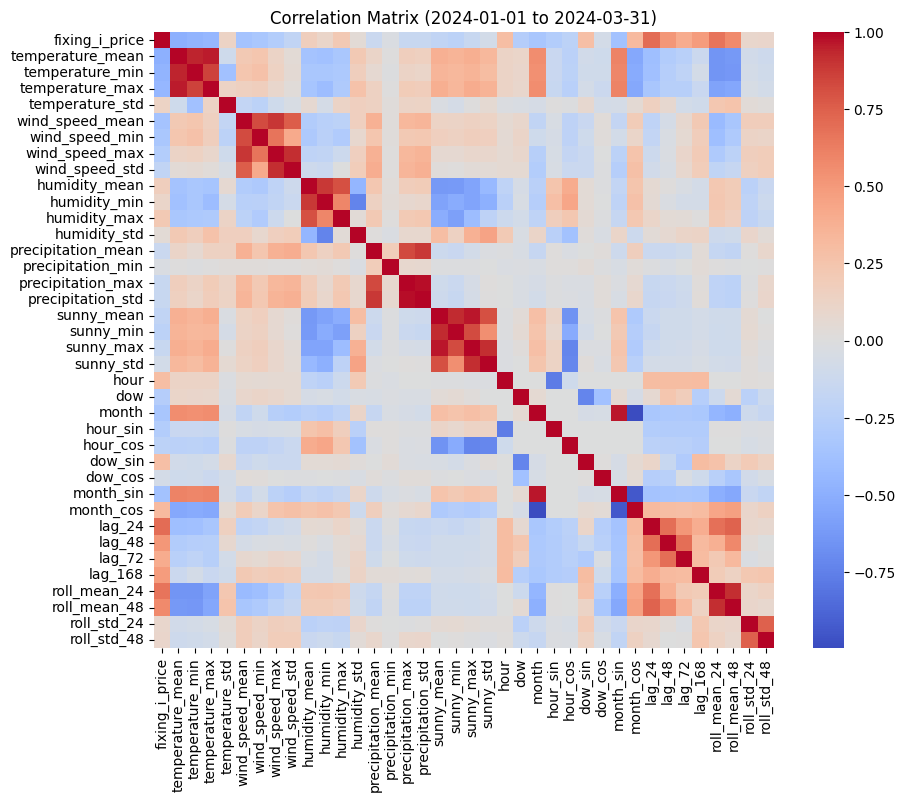

In [50]:
import seaborn as sns

corr = df_slice.loc[:, (df_slice.columns != "delivery_timestamp") & 
                       (df_slice.columns != "business_date")].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap="coolwarm")
plt.title("Correlation Matrix ({} to {})".format(start, end))
plt.show()

### Pairwise relationships

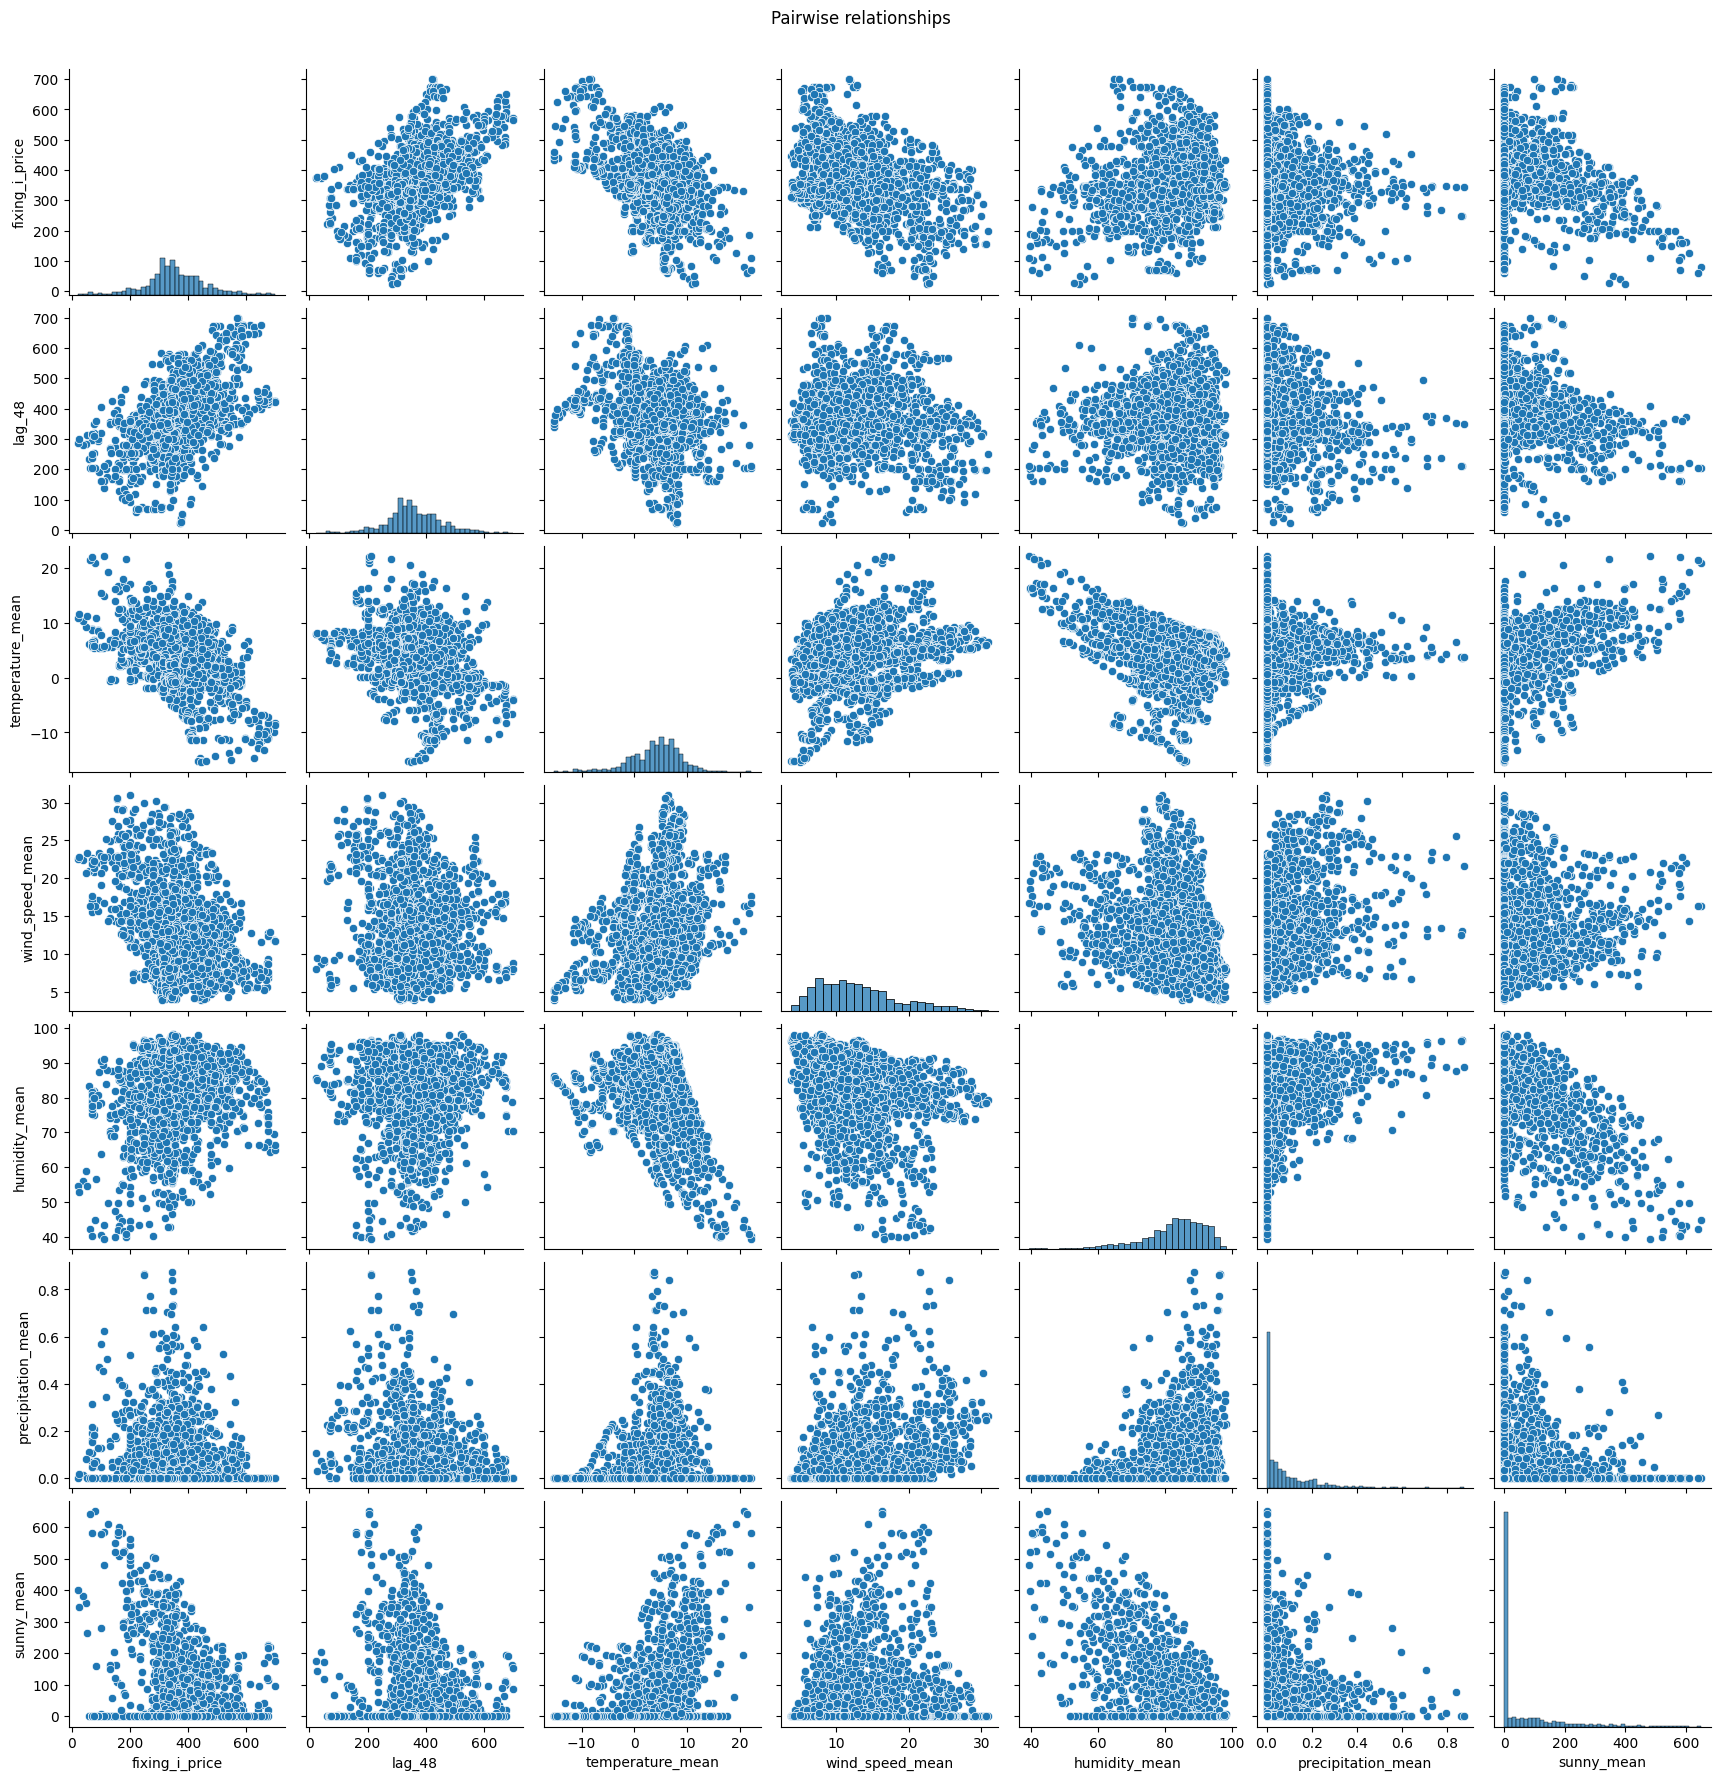

In [55]:
sns.pairplot(df_slice[["fixing_i_price", "lag_48", "temperature_mean", 
                       "wind_speed_mean", "humidity_mean", "precipitation_mean", "sunny_mean"]])
plt.suptitle("Pairwise relationships", y=1.02)
plt.show()

## City features
Now we can try to print some plots related to the single cities data.

Due to the eleveted number of features it would be pointless to print a time series plot, so we could think to print the correlation matrix, that can give us a general idea of the correlation between cities and prices.

In [56]:
import pandas as pd

df = pd.read_csv("../data/output/city_features.csv")
df = df.set_index("delivery_timestamp")
df.rename(columns={"fixing_i_price_first": "fixing_i_price", "business_date_first": "business_date"}, inplace=True)

# choose a specific time window
start, end = "2024-01-01", "2024-03-31"
df_slice = df.loc[start:end]

d:\job_interview\hynfra_data_eng_task\.venv\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
d:\job_interview\hynfra_data_eng_task\.venv\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


<Figure size 1000x800 with 0 Axes>

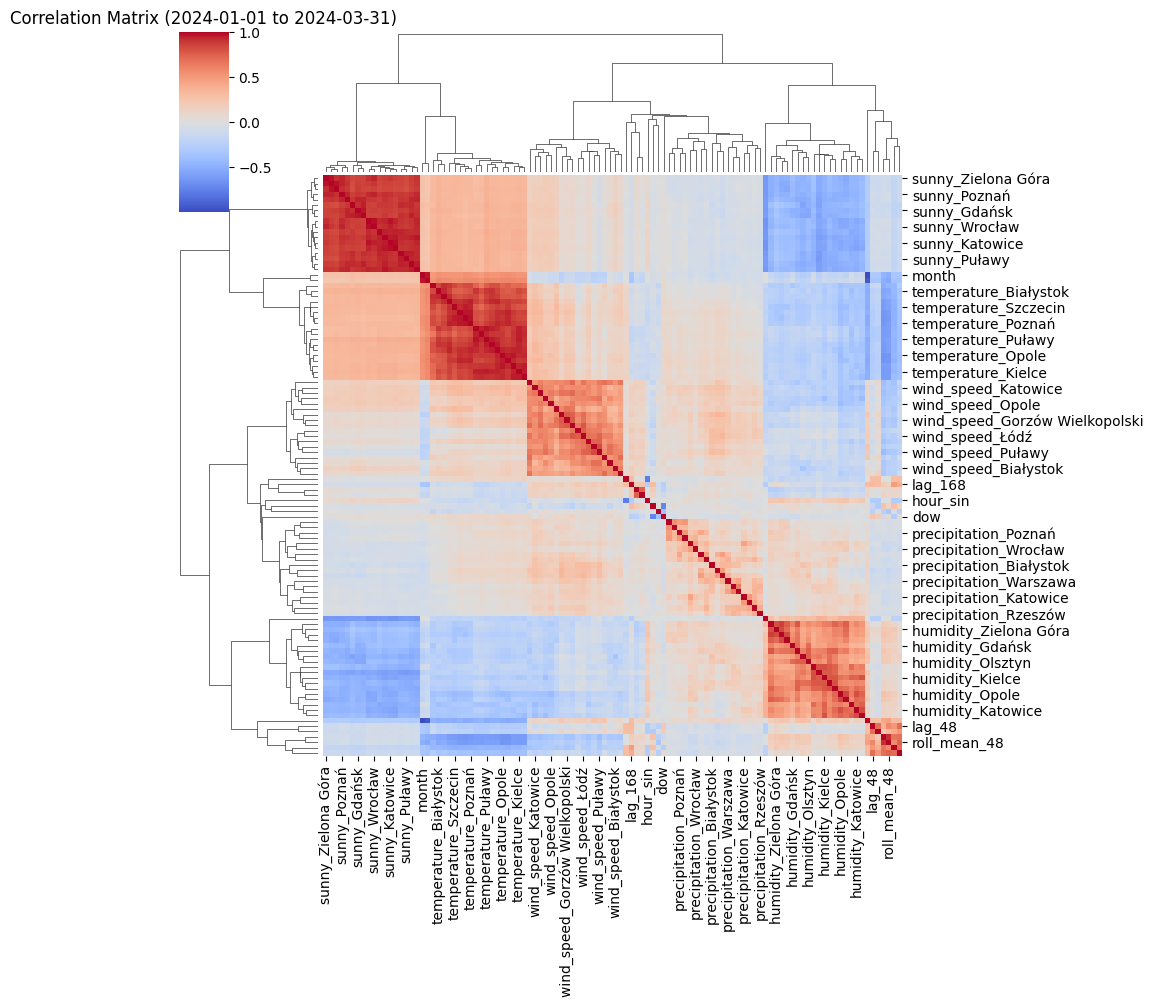

In [ ]:
import seaborn as sns

corr = df_slice.loc[:, (df_slice.columns != "delivery_timestamp") & 
                       (df_slice.columns != "business_date")].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap="coolwarm")
plt.title("Correlation Matrix ({} to {})".format(start, end))
plt.show()

Let's pick 3 random cities to see if there is some sort of correlation with the weather and the price.

Random cities selected: [np.str_('wind'), np.str_('dow'), np.str_('roll')]
Selected columns for correlation: ['wind_speed_Białystok', 'wind_speed_Gdańsk', 'wind_speed_Gorzów Wielkopolski', 'wind_speed_Katowice', 'wind_speed_Kielce', 'wind_speed_Kraków', 'wind_speed_Lublin', 'wind_speed_Olsztyn', 'wind_speed_Opole', 'wind_speed_Poznań', 'wind_speed_Puławy', 'wind_speed_Rzeszów', 'wind_speed_Szczecin', 'wind_speed_Toruń', 'wind_speed_Warszawa', 'wind_speed_Wrocław', 'wind_speed_Zielona Góra', 'wind_speed_Łódź', 'dow', 'dow_sin', 'dow_cos', 'roll_mean_24', 'roll_mean_48', 'roll_std_24', 'roll_std_48', 'fixing_i_price']


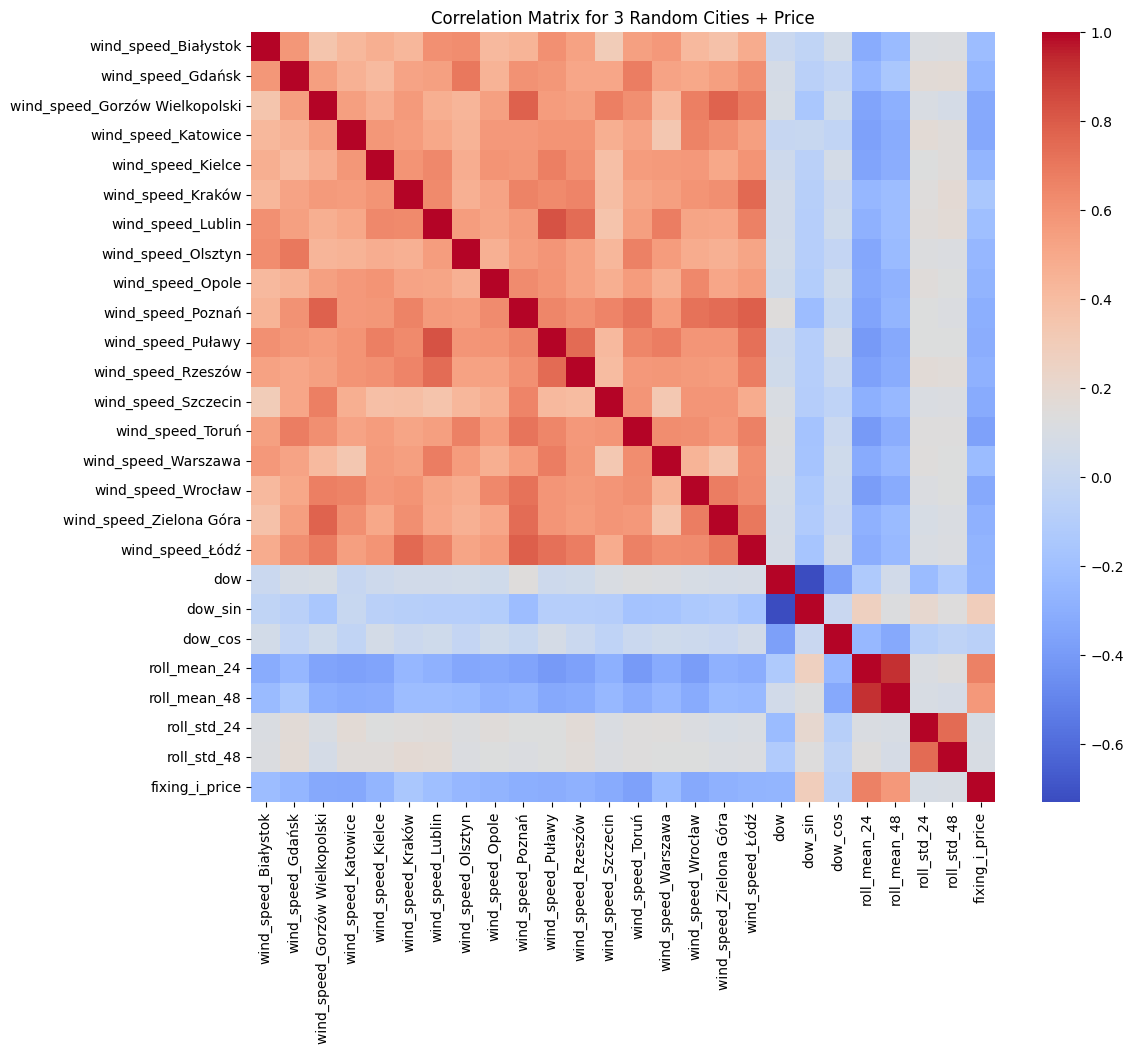

In [86]:
import numpy as np

# Extract city groups from feature names, excluding the target and date columns
city_feature_cols = [c for c in df_slice.columns if c not in ["fixing_i_price", "business_date"]]
city_groups = {}
for col in city_feature_cols:
    parts = col.split("_")
    city = parts[0] if len(parts) > 1 else col
    city_groups.setdefault(city, []).append(col)

city_names = sorted(city_groups)
random_cities = np.random.default_rng(42).choice(city_names, size=min(3, len(city_names)), replace=False)
selected_cols = []
for city in random_cities:
    selected_cols.extend(city_groups[city])

# Keep the price target visible in the correlation matrix
if "fixing_i_price" in df_slice.columns:
    selected_cols.append("fixing_i_price")

print("Random cities selected:", list(random_cities))
print("Selected columns for correlation:", selected_cols)

corr_random = df_slice[selected_cols].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_random, cmap="coolwarm")
plt.title("Correlation Matrix for 3 Random Cities + Price")
plt.show()